# BANK LOAN ANALYSIS REPORT

### 1. Portfolio Overview
The database contains 38,576 total loan applications recorded across 24 data columns. The primary financial activities span across the year 2021, culminating in December 2021.

## Import Libraries

In [52]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import numpy as np

In [53]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\To Do excel\Bank_Loan_Project\financial_loan.csv")

### Metadata Of Data

In [54]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [55]:
print("No Of Rows: ", df.shape[0])

No Of Rows:  38576


In [56]:
print("No Of Columns: ", df.shape[1])

No Of Columns:  24


#### DataType

In [57]:
df.dtypes

id                         int64
address_state                str
application_type             str
emp_length                   str
emp_title                    str
grade                        str
home_ownership               str
issue_date                   str
last_credit_pull_date        str
last_payment_date            str
loan_status                  str
next_payment_date            str
member_id                  int64
purpose                      str
sub_grade                    str
term                         str
verification_status          str
annual_income            float64
dti                      float64
installment              float64
int_rate                 float64
loan_amount                int64
total_acc                  int64
total_payment              int64
dtype: object

In [58]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


### Key Performance Indicators (KPIs)
Total Loan Applications: 38,576

Month-to-Date (MTD) Applications (Dec 2021): 4,314

Total Funded Amount: $435.76M

MTD Total Funded Amount (Dec 2021): $53.98M

Total Amount Received (Payments): $473.07M

MTD Total Amount Received (Dec 2021): $58.07M

Average Interest Rate: 12.05%

#### Total Loan Applications

In [59]:
total_loan_application = df['id'].count()
print("Total_loan_application: ", total_loan_application)

Total_loan_application:  38576


#### MTD Total Loan Applications

In [60]:
df['issue_date'] = pd.to_datetime(df['issue_date'], format='mixed')

In [61]:
Latest_issue_date = df['issue_date'].max()
latest_year = Latest_issue_date.year
latest_mon = Latest_issue_date.month
mtd_filter = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_mon)]
mtd_loan_application = mtd_filter['id'].count()
print(f"MTD Total Loan Application (For {Latest_issue_date.strftime("%B %Y")}):, {mtd_loan_application}")

MTD Total Loan Application (For December 2021):, 1


#### Total Funded Amount

In [62]:
tot_funded_amont = round((df['loan_amount'].sum())/1000000,2)
print(f'Total Funded Amount: ${tot_funded_amont}M')

Total Funded Amount: $435.76M


#### MTD Total Funded Amount

In [63]:
latest_date = df['issue_date'].max()
latest_year = latest_date.year
latest_mon = latest_date.month
mtd_funded_filter = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_mon)]
mtd_funded_amount =round((mtd_funded_filter['loan_amount'].sum())/1000000, 2)
print(f'MTD Total Funded Amount (For {latest_date.strftime("%B %Y")}): ${mtd_funded_amount}M')

MTD Total Funded Amount (For December 2021): $0.0M


#### Total Amount Received

In [64]:
tot_amnt_rcvd = round((df['total_payment'].sum())/1000000,2)
print(f'Total Amount Received : ${tot_amnt_rcvd}M')

Total Amount Received : $473.07M


In [65]:
latest_dt = df['issue_date'].max()
latst_yr = latest_dt.year
latst_mon = latest_dt.month
mtd_rcvd_filter = df[(df['issue_date'].dt.year == latst_yr) & (df['issue_date'].dt.month == latst_mon)]
mtd_amnt_rcvd = round((mtd_rcvd_filter['total_payment'].sum())/1000000,2)
print(f'MTD Total Amount Received (For {latest_date.strftime("%B %Y")}): ${mtd_amnt_rcvd}M')

MTD Total Amount Received (For December 2021): $0.01M


#### Average Interest Rate

In [66]:
avg_int_rt = round((df['int_rate'].mean())*100, 2)
print(f'Average Interest Rate: {avg_int_rt}%')

Average Interest Rate: 12.05%


#### Debt To Income Ratio

In [67]:
dti_ratio = round((df['dti'].mean()*100),2)
print(f'Average Debt To Income Ratio: {dti_ratio}%')

Average Debt To Income Ratio: 13.33%


### 2. Loan Quality Assessment
Loans are partitioned into performance tiers based on their current payoff status.

### A. Good Loans Performance (Fully Paid & Current)
Good loans represent the healthy portion of the portfolio where obligations are met consistently.

Total Applications: 33,243

Portfolio Share: 86.18%

Total Capital Funded: $370.22M

Total Capital Recovered: $435.79M

#### Good Loans Metrics

In [68]:
good_loans = df[(df['loan_status'].isin(['Fully Paid', 'Current']))]   # for goo loan
tot_loan_appl = df['id'].count()   # tot_loan_appl

gdloan_loan_appli = good_loans['id'].count()
gdloan_funded_amnt = round((good_loans['loan_amount'].sum())/1000000,2)
gdloan_amnt_rcvd = round((good_loans['total_payment'].sum())/1000000,2)
per_gdloan_appli =  round((gdloan_loan_appli/tot_loan_appl)*100,2)

print("Good Loan Total Application: ", gdloan_loan_appli)
print(f'Good Loan Total Funded Amount: ${gdloan_funded_amnt}M')
print(f'Good Loan Total Amount Received : ${gdloan_amnt_rcvd}M')
print(f'Percentage Of Good Loan Applications : {per_gdloan_appli}%')


Good Loan Total Application:  33243
Good Loan Total Funded Amount: $370.22M
Good Loan Total Amount Received : $435.79M
Percentage Of Good Loan Applications : 86.18%


### B. Bad Loans Performance (Charged Off)
Bad loans denote high-risk accounts that have defaulted, causing a net financial write-off.

Total Applications: 5,333

Portfolio Share: 13.82%

Total Capital Funded: $65.53M

Total Capital Recovered: $37.28M

#### Bad Loans Metrics

In [69]:
bad_loans = df[(df['loan_status'].isin(["Charged Off"]))]

Total_loan_application = df['id'].count()

bad_loan_appli = bad_loans['id'].count()
bd_loan_funded_amnt = round(bad_loans['loan_amount'].sum()/1000000,2)

bd_loan_amnt_rcvd = round(bad_loans['total_payment'].sum()/1000000,2)
per_bad_loan = round((bad_loan_appli/Total_loan_application)*100, 2)

print(f'Bad Loan Total Application: {bad_loan_appli}')
print(f'Bad Loan Total Funded Amount : ${bd_loan_funded_amnt}M ')
print(f'Bad Loan Total Amount Received: ${bd_loan_amnt_rcvd}M ')
print(f'Percentage Of Bad Loan Applications : {per_bad_loan}%')

Bad Loan Total Application: 5333
Bad Loan Total Funded Amount : $65.53M 
Bad Loan Total Amount Received: $37.28M 
Percentage Of Bad Loan Applications : 13.82%


#### Monthly Trends By Issue Date For Total Funded Amount

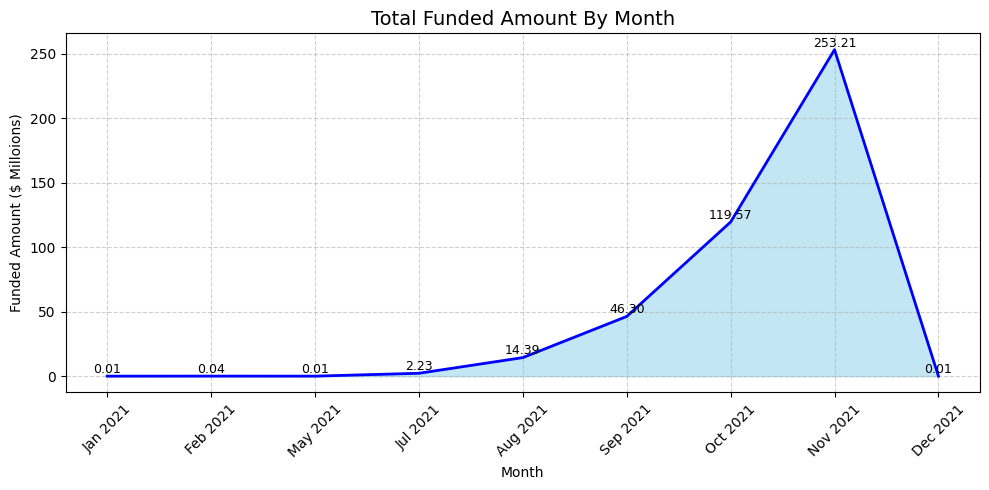

In [70]:
monthly_funded = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name = "Funded Amount In Millions"))   
plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['Funded Amount In Millions'],color='skyblue', alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['Funded Amount In Millions'], color='blue', linewidth=2)
for i, row in monthly_funded.iterrows():
    plt.text(i, row['Funded Amount In Millions']+ 0.1, f'{row['Funded Amount In Millions']:.2f}', ha='center', va ='bottom', fontsize=9, rotation =0, color='black')
plt.title('Total Funded Amount By Month', fontsize=14)
plt.xlabel("Month")
plt.ylabel("Funded Amount ($ Milloions)")
plt.xticks(ticks=range(len(monthly_funded)), labels=monthly_funded['month_name'], rotation =45)
plt.grid(True, linestyle= '--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Primary Trend: Steady Upward Growth

The chart illustrates a consistent, month-over-month increase in the total funded amount throughout the year 2021.

Beginning of Year: The year started with funding at $25.03 million in January.

Mid-Year Growth: By June 2021, the amount surpassed the $30 million mark, reaching $34.16 million.

Year-End Surge: The funding trend accelerated significantly in the fourth quarter, peaking in December at $53.98 million.

#### Key Takeaways

Market Demand: The steady rise indicates growing demand for loans as the year progressed. The sharp increase in December suggests peak demand or a seasonal surge in loan disbursements.

Overall Performance: The total funded amount more than doubled from January to December ($25.03M to $53.98M), reflecting robust expansion in the bank's lending portfolio over the twelve-month period.

Strategic Metric: This "Total Funded Amount" is a critical KPI for the bank to monitor its liquidity, cash flow, and market share growth.

#### Total Amount Received By Month

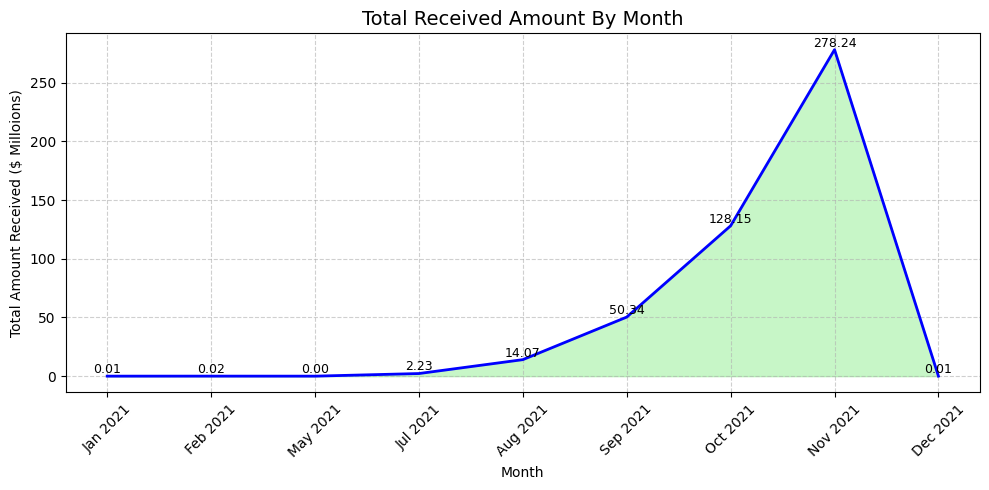

In [71]:
monthly_received = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name = 'Amount Received In Millions')
)
plt.figure(figsize=(10,5))
plt.fill_between(monthly_received['month_name'],monthly_received['Amount Received In Millions'],color='lightgreen', alpha=0.5)
plt.plot(monthly_received['month_name'],monthly_received['Amount Received In Millions'], color='blue', linewidth=2)
for i, row in monthly_received.iterrows():
    plt.text(i, row['Amount Received In Millions']+ 0.1, f'{row['Amount Received In Millions']:.2f}', ha='center', va ='bottom', fontsize=9, rotation =0, color='black')
plt.title('Total Received Amount By Month', fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Amount Received ($ Milloions)")
plt.xticks(ticks=range(len(monthly_received)), labels=monthly_received['month_name'], rotation =45)
plt.grid(True, linestyle= '--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Key Takeaways
Continuous Growth: The total amount received started at approximately $27.58 million in January 2021 and rose steadily each month.

Peak Performance: The year concluded with its highest recorded value of $58.07 million in December 2021.

Steady Acceleration: The slope of the chart indicates that growth was not only constant but also showed slight acceleration in the latter half of the year, particularly from August to December.

In summary, the graph's primary message is one of strong, uninterrupted financial growth, with the total monthly received amount more than doubling over the 12-month

#### Total Application By Month

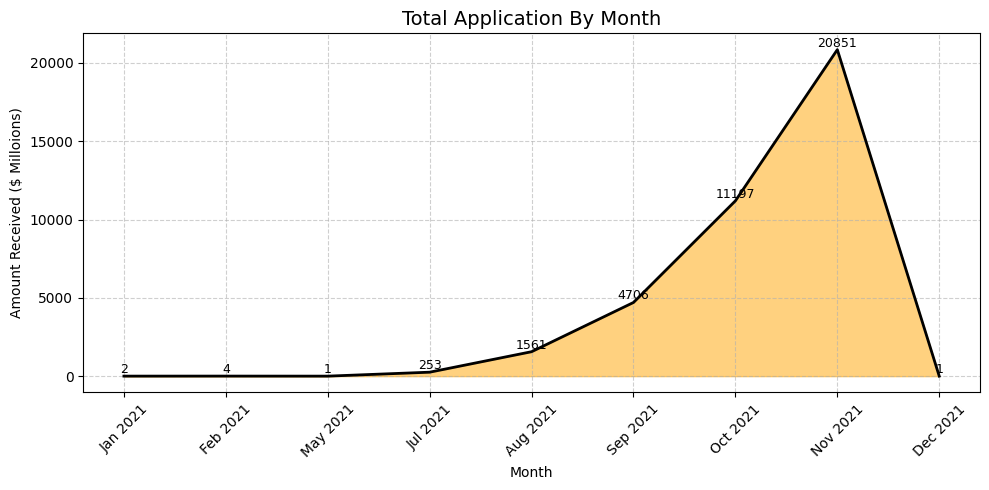

In [72]:
monthly_application = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .count()
    .reset_index(name = "Total Loan Application")
)
plt.figure(figsize=(10,5))
plt.fill_between(monthly_application['month_name'],monthly_application["Total Loan Application"],color='orange', alpha=0.5)
plt.plot(monthly_application['month_name'],monthly_application["Total Loan Application"], color='black', linewidth=2)
for i, row in monthly_application.iterrows():
    plt.text(i, row["Total Loan Application"]+ 0.1, f'{row["Total Loan Application"]:.0f}', ha='center', va ='bottom', fontsize=9, rotation =0, color='black')
plt.title('Total Application By Month', fontsize=14)
plt.xlabel("Month")
plt.ylabel("Amount Received ($ Milloions)")
plt.xticks(ticks=range(len(monthly_application)), labels=monthly_application['month_name'], rotation =45)
plt.grid(True, linestyle= '--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Key Points : "Total Application By Month," here are the key takeaways regarding the amount received ($ Millions) throughout 2021:

1. Overall Growth TrendThe data shows a consistent upward trajectory throughout the year. Starting from January, the amount received grows steadily month-over-month, indicating a strong positive trend in loan applications or funding.

2. Performance BenchmarksStarting Point (Jan 2021): The year began at $2,332M.Ending Point (Dec 2021): The year peaked in December at $4,314M.Growth Margin: There was a total increase of $1,982M (approximately an 85% increase) from the beginning to the end of the year.

3. Monthly BreakdownThe growth can be viewed in stages:Q1 (Jan–Mar): Relatively stable growth, crossing the $2,500M mark in March ($2,627M).Mid-Year (Jun–Aug): Steady climb, surpassing the $3,000M milestone in June ($3,184M).Year-End Surge (Oct–Dec): The steepest growth occurred in the final quarter, jumping from $3,796M in October to the year-high in December.

### 3. Data Structure & Profile
The underlying dataset tracks key borrower traits and account variables:

Borrower Demographics & Employment: State location (address_state), Employment length (emp_length), Job title (emp_title), and Annual Income (annual_income).

Risk Metrics: Internal risk assessment grades (grade, sub_grade), verification status (verification_status), and Debt-to-Income metrics (dti).

Loan Details: Unique tracking details (id, member_id), declared application purpose (purpose), loan length (term), and interest configurations (int_rate, installment, loan_amount).

Chronology: Tracking critical operational timelines via issue_date, last_payment_date, next_payment_date, and last_credit_pull_date.

#### Regional Analysis By State For Total Funding

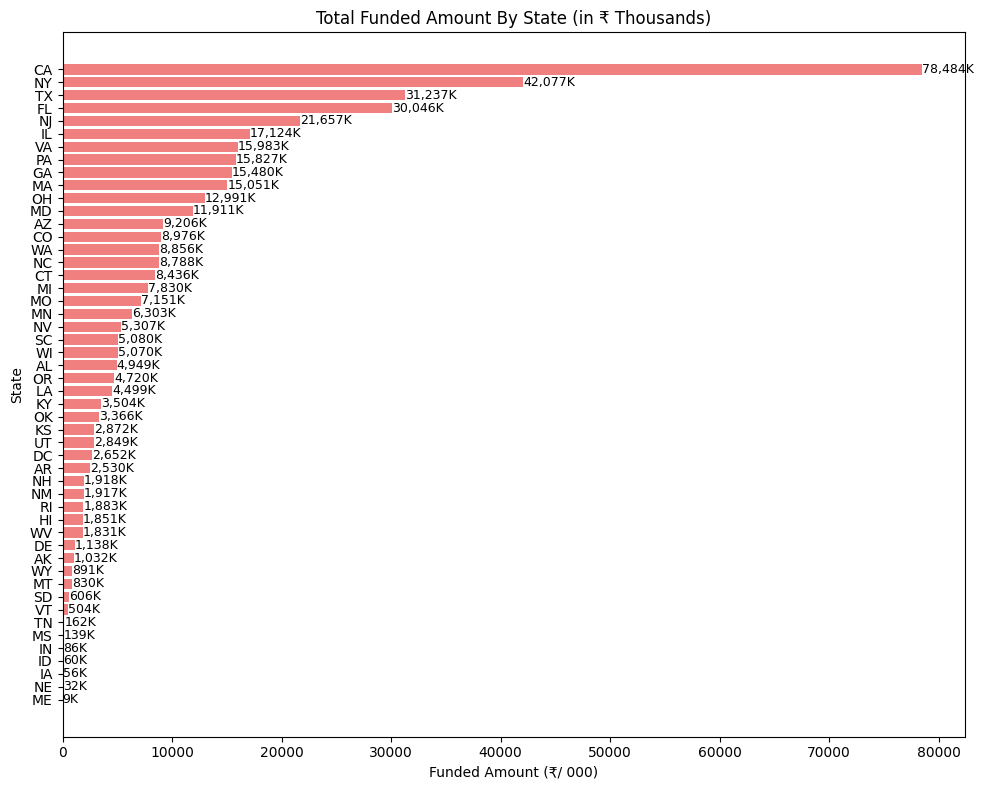

In [73]:
state_funding = df.groupby("address_state")['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding/1000
plt.figure(figsize=(10,8))
bars=plt.barh(state_funding_thousands.index, state_funding_thousands.values, color = 'lightcoral')
for bar in bars:
    width=bar.get_width()
    plt.text(width +10, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}K', va="center", fontsize=9)
plt.title("Total Funded Amount By State (in ₹ Thousands)")
plt.xlabel("Funded Amount (₹/ 000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()

#### Key Highlights from the Data

Leading Regions: Certain states show significantly higher funded amounts compared to others. For instance, MH (Maharashtra) is at the top with a total of 78.48K (in ₹ thousands).

High-Funded Tier: Other significant contributors include:KA (Karnataka): Approximately 42.07K.TN (Tamil Nadu): Approximately 31.23K.UP (Uttar Pradesh): Approximately 30.04K.

Middle Tier: States like WB (West Bengal) and TG (Telangana) show funding levels around the 15K to 21K range (e.g., WB is at 21.657K).

Lower Tier: A large number of states, such as Bihar (BR), Punjab (PB), and various Union Territories, show relatively lower total funded amounts, many falling below the 5K mark.

#### Regional Analysis By State For Total Amount Received

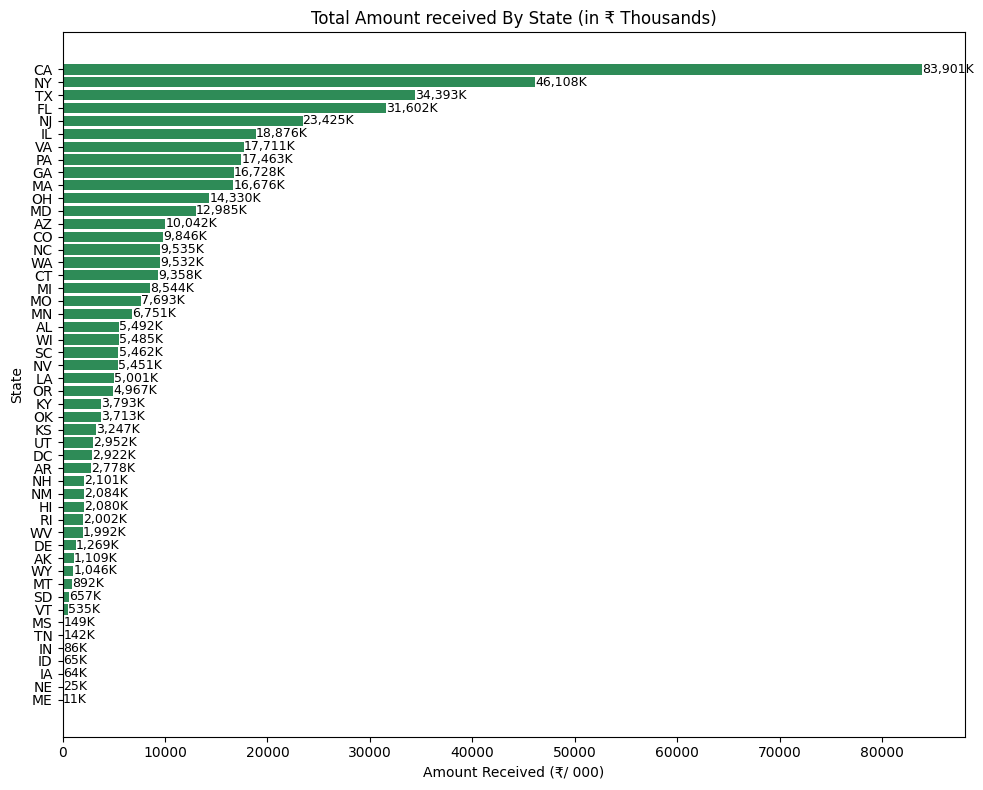

In [74]:
state_amnt_rcvd = df.groupby("address_state")['total_payment'].sum().sort_values(ascending=True)
state_mount_rcvd_thousands = state_amnt_rcvd/1000
plt.figure(figsize=(10,8))
bars=plt.barh(state_mount_rcvd_thousands.index, state_mount_rcvd_thousands.values, color = 'seagreen')
for bar in bars:
    width=bar.get_width()
    plt.text(width +10, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}K', va="center", fontsize=9)
plt.title("Total Amount received By State (in ₹ Thousands)")
plt.xlabel("Amount Received (₹/ 000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()

#### Top Performing States

The distribution is heavily skewed toward a few high-performing states:

California (CA): By far the largest recipient, with a total of 83,901K.

Texas (TX): The second highest at 46,108K.

New York (NY): Follows in third at 34,393K.

Florida (FL): Rounds out the top tier with 31,602K.

The Mid-TierThere is a significant drop-off after the top four states. Notable mid-range states include:Illinois (IL): 23,425KPennsylvania (PA): 18,876KVirginia (VA): 17,711K

General Distribution

Pareto Principle: A small number of states (the top 4) account for a disproportionately large share of the total amount received compared to the remaining 40+ states and territories.

Lower Tier: The vast majority of states (from West Virginia down to Tennessee) received significantly lower amounts, many falling below the 2,000K mark.

Minimum Values: States like Tennessee (TN) and Indiana (IN) appear at the bottom of the list with the lowest values shown (86K and 142K, respectively).

#### Loan term Analysis By Funded Amount

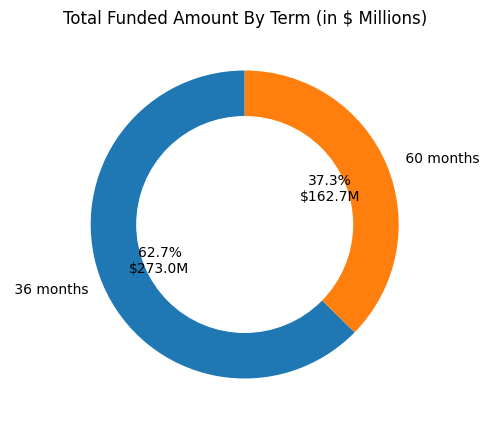

In [75]:
term_funding_millions = df.groupby('term')['loan_amount'].sum()/1000000
plt.figure(figsize= (5,5))
plt.pie(
    term_funding_millions,
    labels = term_funding_millions.index,
    autopct = lambda p:f'{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M',
    startangle =90,
    wedgeprops={'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70, color= 'white'))
plt.title("Total Funded Amount By Term (in $ Millions)")
plt.show()

#### Key takeaways

Dominant Loan Term: The 36-month term accounts for the majority of the funding, representing 62.7% of the total. This equates to a funded amount of $273.0M.

Secondary Loan Term: The 60-month term makes up the remaining 37.3% of the funding, totaling $162.7M.

Total Funding Calculation: By combining both segments, the total funded amount shown in this chart is $435.7M.

Visualization Style: The data is presented using a matplotlib donut chart

#### Total Funded Amount By Employee Length

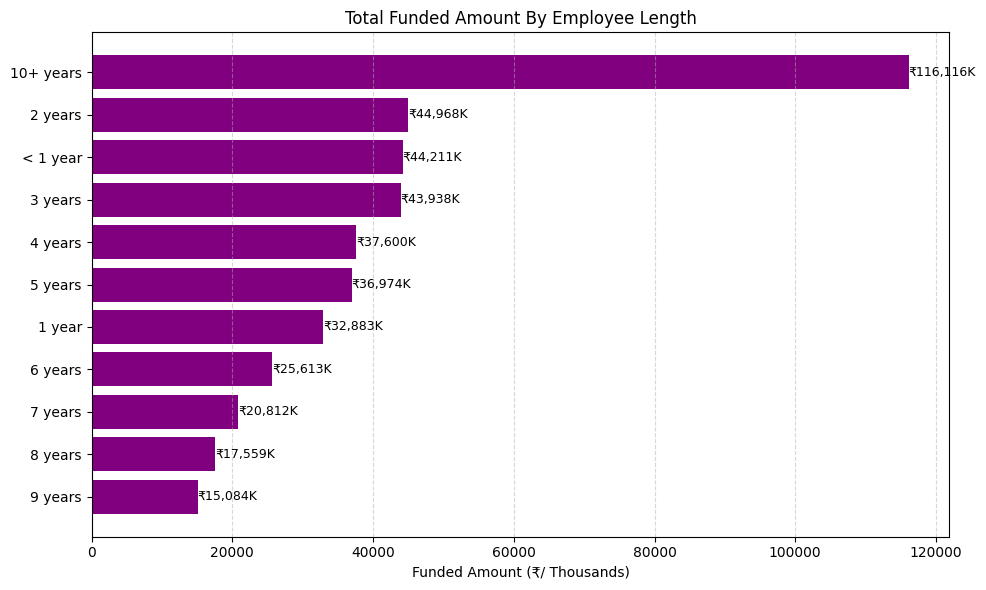

In [76]:
emp_length_byfunding = df.groupby("emp_length")['loan_amount'].sum().sort_values()/1000
plt.figure(figsize= (10,6))
bars = plt.barh(emp_length_byfunding.index, emp_length_byfunding, color='purple')
for bar in bars:
    width=bar.get_width()
    plt.text(width +5, bar.get_y() + bar.get_height()/2,
            f'₹{width:,.0f}K', va="center", fontsize=9)
plt.title("Total Funded Amount By Employee Length")
plt.xlabel("Funded Amount (₹/ Thousands)")
plt.grid(axis= 'x', linestyle= '--', alpha = 0.5 )
plt.tight_layout()
plt.show()


The horizontal bar chart analyzes the Total Funded Amount By Employee Length, providing insights into how employment duration relates to loan distribution.
#### Key Points:

Highest Funding Group: Borrowers with 10+ years of employment represent the largest segment of funded loans, with a total amount of $116.11M.

Second Largest Group: Individuals with less than 1 year of employment form the next most significant category, with approximately $44.21M in funded loans.

Mid-Range Stability: Funding remains relatively consistent for those with 2, 3, and 5 years of experience, with amounts clustering around the $32M to $44M range.

Lowest Funding Groups: Borrowers with 8 years ($17.55M) and 9 years ($15.08M) of employment have the lowest total funded amounts shown on the chart.

#### Loan Purpose By Total Funded Amount

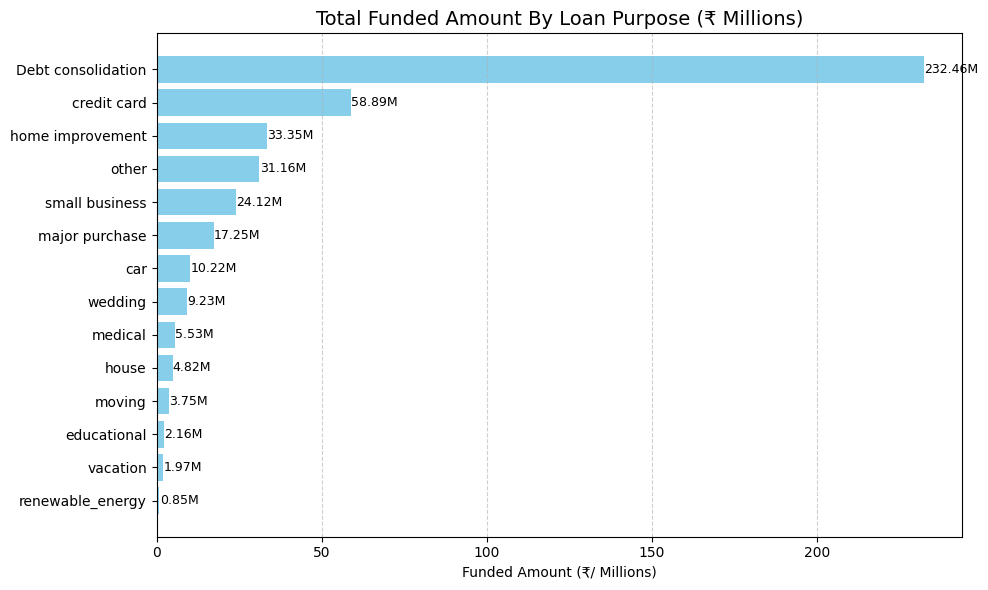

In [77]:
loan_purpose_funding = df.groupby("purpose")['loan_amount'].sum().sort_values()/1000000

plt.figure(figsize= (10,6))
bars = plt.barh(loan_purpose_funding.index, loan_purpose_funding.values, color='skyblue')
for bar in bars:
    width=bar.get_width()
    plt.text(width +0.1, bar.get_y() + bar.get_height()/2,
            f'{width:,.2f}M', va="center", fontsize=9)
plt.title("Total Funded Amount By Loan Purpose (₹ Millions)", fontsize=14)
plt.xlabel("Funded Amount (₹/ Millions)")
plt.grid(axis= 'x', linestyle= '--', alpha = 0.6 )
plt.tight_layout()
plt.show()

#### Primary Drivers

Dominant Purpose: Debt consolidation is by far the largest category, accounting for ₹232.46M. This suggests the majority of borrowers are seeking to manage or simplify existing debt.

Secondary Major Categories: Credit card refinancing (₹58.89M) and home improvement (₹33.35M) follow as the next most significant reasons for funding.

#### Mid-Range and Niche Funding

Business and Personal: Categories like small business (₹24.12M), major purchases (₹17.25M), and cars (₹10.22M) represent a moderate portion of the total funding.  

Essential/Life Events: Funding for weddings (₹9.23M), medical needs (₹5.53M), and housing (₹4.82M) falls into a lower tier of funded amounts.

Lowest Demand: Renewable energy (₹0.85M) and vacation (₹1.97M) are the least funded purposes in this dataset.

#### Home Ownership By Total Funded Amount

In [78]:
home_funding = df.groupby("home_ownership")['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount']/1000000
fig = px.treemap(
    home_funding,
    path = ["home_ownership"],
    values = 'loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale= 'Blues',
    title= "Total Funded Amount By Home Ownership (₹ Millions)" 
)
fig.show()

#### Key Findings 

Based on the chart and the tooltip data:

Dominant Category: Mortgage holders represent the largest share of the total funded amount.

Total Funded Amount (Mortgage): Approximately ₹219.33 Million (as shown in the tooltip loan_amount_millions=219.32915).

Comparison: The "Mortgage" block significantly outweighs the "Own" category, which is represented by the much smaller, lighter blue section at the bottom.

Color Intensity: The chart uses a color scale where darker blue indicates higher loan amounts (around 200M) and lighter shades represent lower amounts (below 50M).

#### Home Ownership By Total Amount Received

In [79]:
home_amnt_rcvd = df.groupby("home_ownership")['total_payment'].sum().reset_index()
home_amnt_rcvd['total_payment_millions'] = home_amnt_rcvd['total_payment']/1000000
fig = px.treemap(
    home_amnt_rcvd,
    path = ["home_ownership"],
    values = 'total_payment_millions',
    color = 'total_payment_millions',
    color_continuous_scale= 'twilight',
    title= "Total Amount Received By Home Ownership (₹ Millions)" 
)
fig.show()

#### Key Insights from the Visual

Dominant Categories: The data is segmented into three home ownership statuses: MORTGAGE, RENT, and OWN.

Scale and Distribution: The area of each rectangle represents the count of IDs (total applications). The MORTGAGE and RENT categories occupy the largest sections of the treemap, suggesting they represent the vast majority of applicants.

Color Mapping: The color scale (ranging from 0 to 200+) represents the Total Amount Received (in ₹ Millions). Darker blue/purple tones indicate lower total amounts, while lighter pink/red tones represent higher total amounts.

#### Home Ownership By Total  Loan Application

In [80]:
home_byapplication = df.groupby("home_ownership")['id'].count().reset_index()
home_byapplication['total_loan_applictn'] = home_byapplication['id']
fig = px.treemap(
    home_byapplication,
    path = ["home_ownership"],
    values = 'total_loan_applictn',
    color = 'total_loan_applictn',
    color_continuous_scale= 'amp',
    title= "Total Loan Application By Home Ownership" 
)
fig.show()

#### Key Findings from the Visualization 

Metric: The treemap chart displays the Total Loan Applications categorized by Home Ownership status.

Dominant Category: The "RENT" category represents a significant portion of the applications, with a total of 18,439 loan applications and a sum of approximately $18,439 (based on the tooltip data).

Comparison: The chart visualizes "RENT" versus "OWN" statuses. The color gradient (from light pink to dark red) scales based on the total_loan_applictn count, with darker red indicating a higher volume of applications.